In [3]:
import numpy as np
import matplotlib.pyplot as plt


# Monte Carlo Simulation for Agile Estimation
## Project Definition and Significance
In today's dynamic and fast-paced technology landscape, companies increasingly rely on their software teams to deliver quickly and predictably. A particularly prominent challenge within my current work environment is being asked daily: "What is the ETA?"

Often, these questions arise before there is a business case, sufficient requirements, or even a basic technical analysis. Teams are effectively asked to commit to completion dates under conditions of uncertainty. Even for seemingly repetitive work, there are numerous factors that must be considered and accounted for. While widely adopted Agile best practices exist, they don't always serve organizations well and often "speak" in a language that stakeholders and clients struggle to comprehend.

What is universally understandable and unambiguous are dates. There is only one March 17th on the calendar. When management asks for an ETA, they want a concrete date not story points, not velocity, not relative estimates. This fundamental mismatch between how teams estimate and how stakeholders think creates friction, missed expectations, and eroded trust.

This purpose of this project is to explore whether Monte Carlo simulation can bridge this gap by transforming historical work data into probabilistic date based forecasts that stakeholders can understand while still respecting the inherent uncertainty of software development. For that purpose throughout this project examples from my current anr/or past teams will be used.

## Current State: Point Estimates
One of the most widely popular best practices for estimation in the Agile world is the point estimate, often based on the Fibonacci sequence or t-shirt sizing (XS, S, M, L, XL). Point estimation is relative by definition and nature it combines estimations of effort, complexity, and uncertainty into a single abstract number. The idea is that over time, a team's velocity (points completed per sprint) becomes predictable, allowing for more predictable planning.There is nothing wrong with this estimation method. When used correctly in the right environment, it can work well. However, it does not work well universally. There are certain prerequisites that need to be in place to utilize point estimation to its full potential:
 - Stable team composition - the same team members working together over multiple sprints
 - Collaborative estimation - all stakeholders (developers, QA, product owners) involved in the estimation process
 - Shared understanding - everyone aligned on what a 5SP means for this specific team and understanding it will not mean the same for another team

In practice, these prerequisites are often not met. Remote work environments make it challenging to gather all stakeholders for estimation sessions. Teams frequently face pressure to provide ETAs on a weekly basis with minimal context. New team members join, experienced ones leave, and work types vary significantly. Most critically, story points don't translate directly to dates, which is what stakeholders actually need. Even when story points work well for internal team planning, they create a communication barrier with business stakeholders who think in terms of calendar dates, not abstract velocity metrics and resist change management in this direction.
## Why Point Estimates Fail: A Mathematical Perspective

Point estimates by definition assume that similar work takes a consistent, predictable duration. Even in an ideal environment where all prerequisites for estimation are met this assumption fails when the underlying work has inherent variability. In my current work environment one type of work we perform frequently is integrations with third-party software applications. Our team's communicated point estimate for these integrations is T-shirt size M, which by team definition translates to approximately 2 calendar weeks or 14 days. While the rationale behind this estimate is not formally documented, empirical data from past integrations reveals a significant gap between this communicated timeline and actual delivery performance. Each integration follows the same development process, yet outcomes vary significantly due to factors such as API documentation quality, unexpected edge cases, and team capacity fluctuations. To demonstrate this discrepancy mathematically, I will use the Empirical Cumulative Distribution Function (ECDF) to compare the point estimate assumption against observed reality.

The Empirical Cumulative Distribution Function is defined as [1]:
$$\hat{F}_n(x) = \frac{\text{Number of elements in sample} \; \leq \; x}{n} = \frac{1}{n} \sum_{i=1}^{n} I(X_i \leq x)$$

This function answers: *"What proportion of integrations finished by day x?"*

I will be using real data from Jira which captures such integrations completed over the past year. For the purpose of this project, the following assumptions and limitations are made:

* Raw data used - outliers are included rather than filtered, as they represent real occurrences of high-complexity integrations that stakeholders experience
* Calendar days - Jira tracking includes weekends; actual working days are approximately 5/7 of reported duration but we use calendar days as this reflects stakeholder perception of "how long it took"
* Data quality not validated - Jira entries may contain inaccuracies (delayed ticket updates, incorrect status changes) but are used as is to reflect operational reality
* Tracking accuracy - no adjustments made for time tickets spent in "waiting" states (code review or blocked) vs active development time as this is also part of the operational reality

These limitations mean the data represents elapsed calendar time rather than pure development effort, but this is the metric stakeholders care about when asking "When will this be done?"

The raw data and cleaning process are documented in the `/data` folder as a `.csv` file, the `raw_jira_data` list is compiled based on filtering the data for *Completion Status = Completed* and *Current Status = Done* 


In [8]:
raw_jira_data = [4,7,20,7,8,32,3,1,21,8,73,1,7,12,1,24,26,13,16,3,48,26,74,2,20,4,0,13,24,6,5,22,180,11,32,15,34,55,29,32,1,28,54,76,25,46,48,49,46,21,29,47,37,40,2,84,56,9,8,37,94,38,28,29,28,30,67,41,50,34,44,36,1,25,22,22,55,0,15]

#Since the raw data includes very small values bellow 5 and some extreme high values such as 180, a simple clean up will be performed with threshold of 90 days.
#Why 90? This is roughly 3 months, if an integration took more than 3 months there was a extraordinary situation that caused it like capacity shift or team member leaving
threshold = 90
integration_actual_days = [x for x in raw_jira_data if x > 4 and x <= threshold]

In [7]:
def plot_integration_cdf(integration_actual_days, point_estimate):
    sorted_data = np.sort(integration_actual_days)
    n = len(sorted_data)
    max_x = max(sorted_data)
    
    #For this experiment I will use the Empirical Cumulative Distribution Function (ECDF) to represent the integration as per the data from Jira and the point estimation
    empirical_cdf_values = np.arange(1, n + 1) / n
    x_range = np.linspace(0, max_x+1, 1000)
   
    #For each x, count how many data points are ≤ x as per definition
    empirical_cdf_smooth = np.zeros_like(x_range)
    for i, x in enumerate(x_range):
        count = np.sum(np.array(integration_actual_days) <= x)
        empirical_cdf_smooth[i] = count / n
    
    #Point Estimate ECDF
    point_estimate_cdf = np.where(x_range >= point_estimate, 1.0, 0.0)
    
    #Probability of finishing by the point estimate (day 14)
    prob_at_estimate = np.sum(np.array(integration_actual_days) <= point_estimate) / n
    #75th percentile - quite confident an integration will be completed, considering some urgency from business
    p75_day = np.percentile(integration_actual_days, 75)
    
    #85th percentile - high probability an integration will be completed
    p85_day = np.percentile(integration_actual_days, 85)
    
    #Visualizing the data on a chart
    fig, ax = plt.subplots(figsize=(14, 8))
    
    #Plot the empirical CDF (smooth) from Jira data
    ax.plot(x_range, empirical_cdf_smooth, linewidth=3, color='steelblue', 
            label='Reality (Empirical CDF)', zorder=3)
    
    #Plot the point estimate CDF (step function) from point estimation
    ax.plot(x_range, point_estimate_cdf, linewidth=3, color='red', 
            linestyle='--', label=f'Point Estimate CDF: {point_estimate} days', zorder=2)
    
    #Add vertical line at point estimate
    ax.axvline(point_estimate, color='red', linestyle=':', linewidth=2, 
               alpha=0.5, zorder=1)
    
    #Highlight the key point: probability at point estimate 14 days
    idx_estimate = np.argmin(np.abs(x_range - point_estimate))
    cdf_at_estimate = empirical_cdf_smooth[idx_estimate]
    ax.plot([point_estimate], [cdf_at_estimate], 'ro', markersize=12, zorder=4)
    
    #Lines for 75 and 85 percentile probablities
    ax.axvline(p75_day, color='orange', linestyle='--', linewidth=2, 
               alpha=0.6, label=f'75th Percentile: {p75_day:.0f} days')
    ax.axvline(p85_day, color='green', linestyle='--', linewidth=2, 
               alpha=0.6, label=f'85th Percentile: {p85_day:.0f} days')
    
    #Mark the P75 and P85 on the CDF curve
    idx_p75 = np.argmin(np.abs(x_range - p75_day))
    ax.plot([p75_day], [empirical_cdf_smooth[idx_p75]], 'o', color='orange', markersize=10, zorder=4)
    idx_p85 = np.argmin(np.abs(x_range - p85_day))
    ax.plot([p85_day], [empirical_cdf_smooth[idx_p85]], 'o', color='green', markersize=10, zorder=4)
    
    #Labels and title
    ax.set_xlabel('Days', fontsize=14, fontweight='bold')
    ax.set_ylabel('Cumulative Probability', fontsize=14, fontweight='bold')
    ax.set_title('Cumulative Distribution Function (CDF)\n"What % of integrations finish by day X?"', 
                 fontsize=16, fontweight='bold', pad=20)
    
    #Grid, legend and axis limits
    ax.grid(alpha=0.3, linewidth=0.5)
    ax.legend(fontsize=11, loc='lower right', framealpha=0.9)
    ax.set_xlim(0, max_x+1)
    ax.set_ylim(0, 1.05)
    plt.show()
    
    return prob_at_estimate, p75_day, p85_day

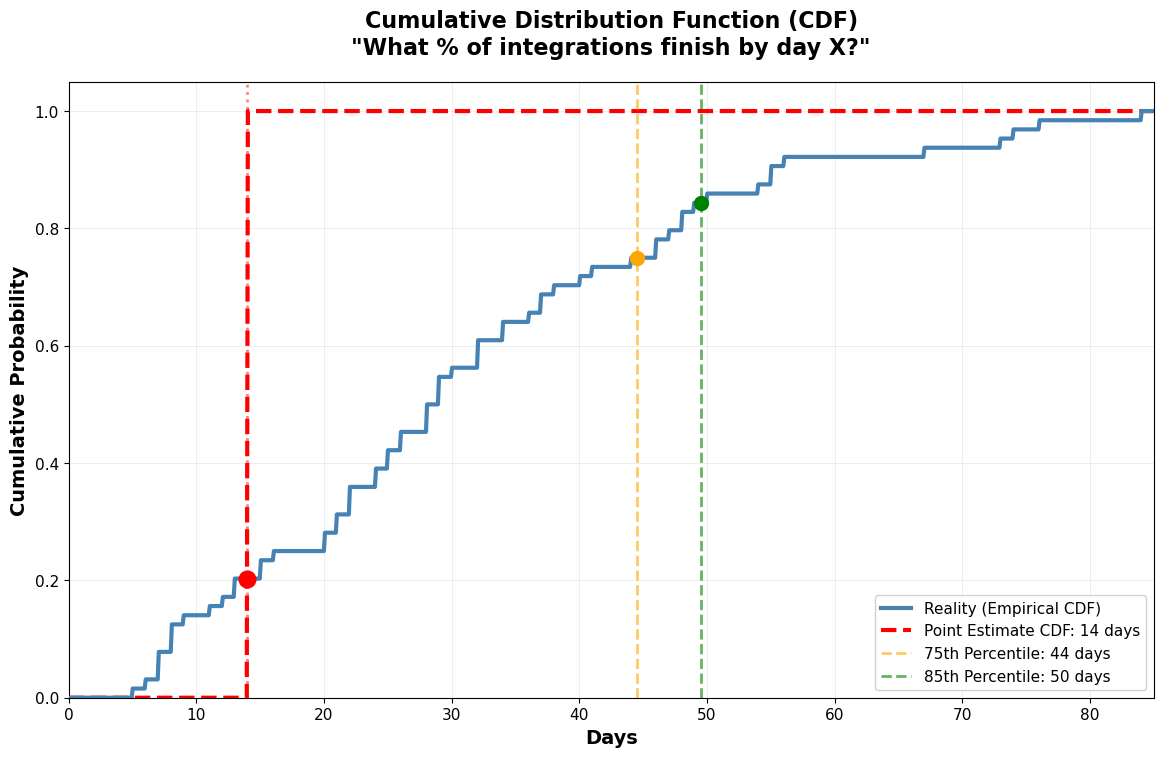

In [60]:
prob, p75, p85 = plot_integration_cdf(integration_actual_days, point_estimate=14)

Now that we have the CDF chart which illustrates the cumulative probability of "What % of integrations finish by day x" lets look into the **histogram** of the integration data. The histogram will help illustrate the frequency distribution,  where the data clusters as well as the shape of the distribution. 

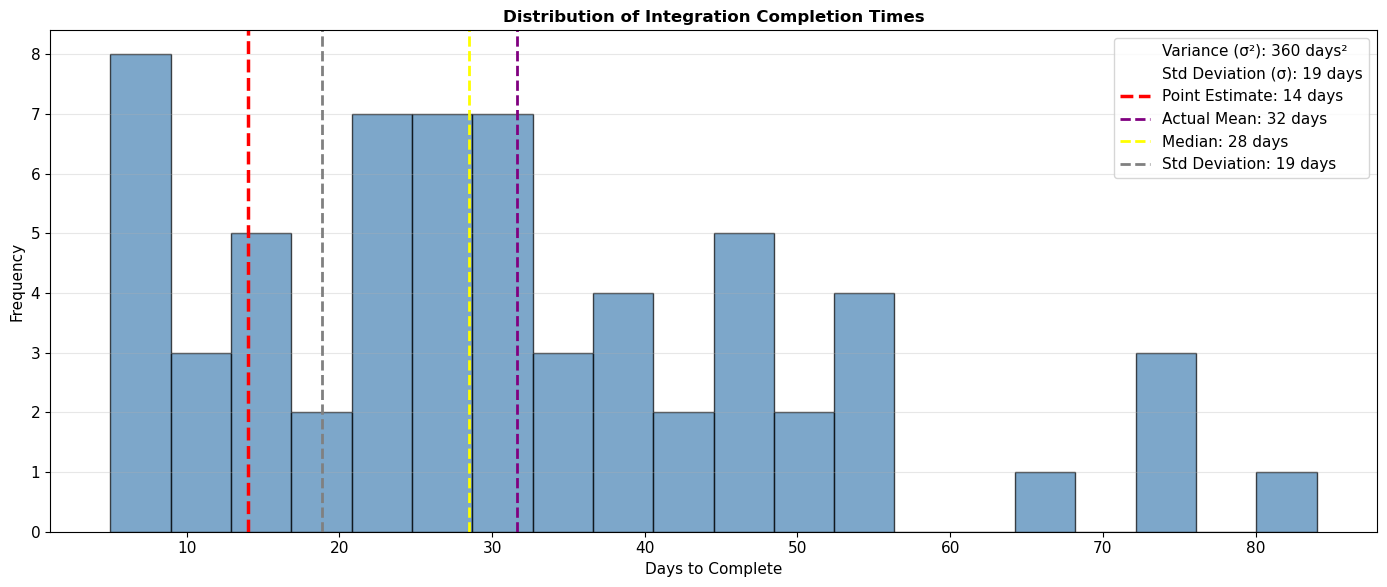

In [76]:
fig, ax = plt.subplots(figsize=(14, 6))

#Actual variance and standard deviation
variance = np.var(integration_actual_days, ddof=1) 
std_dev = np.std(integration_actual_days, ddof=1)

#Adding variance and std_dev to the legend
ax.plot([], [], ' ', label=f'Variance (σ²): {variance:.0f} days²')
ax.plot([], [], ' ', label=f'Std Deviation (σ): {std_dev:.0f} days')


#Histogram visualization
ax.hist(integration_actual_days, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(14, color='red', linestyle='--', linewidth=2.5, label='Point Estimate: 14 days')

#Getting the mean and median
ax.axvline(np.mean(integration_actual_days), color='purple', linestyle='--', linewidth=2, 
           label=f'Actual Mean: {np.mean(integration_actual_days):.0f} days')
ax.axvline(np.median(integration_actual_days), color='yellow', linestyle='--', linewidth=2,
           label=f'Median: {np.median(integration_actual_days):.0f} days')
ax.axvline(np.std(integration_actual_days), color='grey', linestyle='--', linewidth=2,
           label=f'Std Deviation: {np.std(integration_actual_days, ddof=1):.0f} days')

#Setting legend and grid
ax.set_xlabel('Days to Complete', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Integration Completion Times', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation: Why Point Estimates Fail - Evidence from Data

The histogram and CDF together provide substantial evidence that point estimates are fundamentally inadequate for software estimation work, especially in my current work environment.

#### What the Visualizations Reveal?
**Histogram (frequency distribution):**
- Multimodal spread - integration times cluster in two distinct groups (around 10 days and around 30 days) with a long tail extending to 84 days
- High variance - standard deviation of 19 days means outcomes vary dramatically despite following the same process
- Point estimate falls in a gap - the 14 day estimate sits between clusters, representing neither the "easy" nor "typical" integration
- Systematic underestimation - median of 28 days is exactly twice the promised 14 days; mean of 32 days is 2.3 times higher

**CDF (cumulative probability):**
- Only 20% success rate - when we promise 14 days, only 20% of integrations actually finish on time
- Realistic forecasts require 3-3.6 times more days needed: 
  - 75% confidence (P75): 44 days (3.14 times the point estimate)
  - 85% confidence (P85): 50 days (3.6 times the point estimate)

#### The Mathematical Core of the Problem

Point estimates assume a **Dirac delta distribution**[2] - all probability concentrated at a single value:

$$P(T = 14) = 1, \quad P(T \neq 14) = 0$$
$$\implies \sigma^2 = 0 \text{ (zero variance, zero uncertainty)}$$

Reality, as shown in the histogram and CDF, follows an **empirical distribution** with probability spread across many values (5 to 84 days):

$$\sigma^2 = 360.3 \text{ days}^2, \quad \sigma = 19.0 \text{ days}$$

#### Why Does This Variance Exist?

Each integration follows the same development process in its core:
1. Review API documentation
2. Implement authentication  
3. Build core integration logic
4. Handle errors and edge cases
5. Write tests
6. Code review
7. Deploy to staging
8. Test on staging
9. Deploy to production (completed integration)

Yet outcomes vary from 5 to 84 days!!!

- External factors beyond team control - API documentation quality, 3rd party support responsiveness, undocumented behaviors
- Emergent complexity - edge cases only discovered during implementation
- Human factors - code review timing, competing priorities, team capacity fluctuations, developer experience level

These sources of variance are critical and cannot be eliminated through better estimation alone.

#### Why Point Estimates Fail?

**1. They communicate false precision**
- Saying "14 days" implies high confidence and narrow uncertainty
- Reality: 79-day range with 19 day standard deviation ($\text{Range = Maximum − Minimum}$)
- **Result**: Stakeholders are misled into believing work is quick and predictable when it isn't

**2. They ignore variance mathematically**  
- Point estimate treats duration as a constant: T = 14
- Reality: duration is a random variable: T ~ Distribution($\mu = 32$, $\sigma = 19$)
- **Result**: Forecasts are systematically optimistic and uncalibrated (20% success rate $\neq$ implied 100% certainty)

**3. They cannot express risk or confidence**
- Point estimate: "It will take 14 days" (no probability, no alternatives)
- What stakeholders actually need: "75% chance by day 44 if a,b,c conditions are met or 85% chance by day 50" or a more probablistic range
- **Result**: No framework for risk-based planning or setting appropriate buffers at the current estimation process

### Conclusion: The Need for Probabilistic Forecasting
The analysis of my current team's integration work demonstrates a pattern common across software development: point estimates systematically fail when applied to work with inherent variance. While the specific numbers and results reflect this particular team's reality, the underlying problem is widely spread: knowledge work has uncertainty that single-number estimates cannot represent.

**Why Monte Carlo Simulation?**

Monte Carlo simulation is selected as the subject to put to test as a forecasting approach for this project because it fundamentally shifts from deterministic promises to probabilistic forecasts:

1. Uses empirical data rather than assumptions - Instead of guessing at distributions or relying on expert judgment, Monte Carlo samples directly from observed history, making no assumptions about the "shape" of uncertainty.

2. Outputs probability distributions, not false certainty - Rather than claiming "it will take X days," Monte Carlo produces "Y% probability by day X," enabling stakeholders to choose confidence levels based on their risk tolerance OR for our team to tailor the delivery date based on internal factors and the business needs.

3. Scales naturally to multiple items - When forecasting multiple work items, Monte Carlo accounts for variance accumulation through repeated sampling, addressing the compounding uncertainty that point estimates ignore.

4. Remains transparent and explainable - Unlike complex statistical models requiring specialized knowledge, Monte Carlo's core logic "randomly sample from history many times, observe the distribution of outcomes" is intuitive enough to explain to non-technical stakeholders and will allow to tailor results using multiple parameters.

**Why not other techniques?**

Alternative approaches were considered but not pursued:
- Story points + velocity still collapse to point estimates and inherit the same variance-blind limitations
- Three-point estimation (PERT) assumes distributions (typically normal) and relies on subjective optimistic/pessimistic guesses rather than empirical data
- Parametric statistical models require distribution fitting and sample sizes larger than most teams possess

Monte Carlo offers the optimal balance: grounded in real data, probabilistic in output, simple in concept, and practical in application.

This project will explore whether this theoretical promise holds in practice specifically, under what conditions Monte Carlo forecasting produces calibrated, useful predictions for Agile teams, and when its assumptions break down.

### Resources:

[1]. Wikipedia - https://en.wikipedia.org/wiki/Empirical_distribution_function

[2]. Lamar University - https://tutorial.math.lamar.edu/classes/de/diracdeltafunction.aspx